## STEP 1: GATHER DATA ##

## Problem Statement ##

The goal of this project is to analyze the relationship between Electric Vehicle (EV) adoption and the availability of public charging infrastructure in Washington state, with a specific focus on King County. I will be wrangling an API dataset containing all registered public electric vehicle charging stations from the National Renewable Energy Laboratory (NREL) alongside EV registration data from Washington State.

**Dataset 1 (API Method)**

I chose the following dataset to observe the public electric vehicle infrastructure in our local area, having personally experienced the challenge of finding fast chargers. The data gathering method required extracting JSON data by accessing the National Renewable Energy Laboratory (NREL) API and loading it into a pandas DataFrame. The key variables are 'station_name' to identify the charger, 'zip' for its locations, and 'ev_dc_fast_num', providing the count of high-speed charging infrastructure available at a specific site.

In [ ]:
import requests
import pandas as pd

api_url = "https://developer.nrel.gov/api/alt-fuel-stations/v1.json?api_key=&state=WA&fuel_type=ELEC"

In [3]:
#Make the GET request
response = requests.get(api_url)

In [4]:
#Parse the JSON response
station_data = response.json()

In [5]:
#Load the 'fuel stations' list into Pandas Dataframe
df_stations = pd.DataFrame(station_data['fuel_stations'])

In [6]:
#Check data
df_stations[['station_name', 'city','zip','ev_dc_fast_num']].head()

,station_name,city,zip,ev_dc_fast_num
0,Seattle-Tacoma International Airport - General...,Seattle,98188,NaN
1,Avista Corp,Spokane,99252,NaN
2,Steam Plant Parking,Spokane,99201,NaN
3,BELLEVUE BELLEVUE CH 1,Bellevue,98004,NaN
4,KING COUNTY DES ISSAQUAH P&R 2,Issaquah,98027,NaN


**Dataset 2 (Programmatic CSV Download)**

I selected this dataset to analyze the number of electric vehicle (EV) users and its concentration across different regions in Washington state. I chose to programmatically download a CSV file directly from Washington state data.gov URL using the pandas 'read_csv' function. The significant variables for this analysis are 'Model' to calculate the total number of registered EVs, and 'Postal Code' to allow the grouping of vehicles by region and merge them with the charging station dataset.

In [7]:
#Define the URL for the CSV download (found on data.gov)
csv_url = "https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD"

#Load the CSV directly into a DataFrame
df_ev_registrations = pd.read_csv(csv_url)

#check data
df_ev_registrations[['County', 'City', 'Postal Code', 'Make', 'Model']].head()

,County,City,Postal Code,Make,Model
0,Yakima,Yakima,98902.0,TESLA,MODEL 3
1,King,Kent,98030.0,NISSAN,LEAF
2,Snohomish,Marysville,98271.0,JEEP,WRANGLER
3,Snohomish,Bothell,98012.0,AUDI,Q5 E
4,King,Seattle,98125.0,NISSAN,LEAF


## STEP 2: ASSESS DATA ##

In [8]:
#Viewing first few rows to inspect
df_stations.head()

,access_code,access_days_time,access_detail_code,cards_accepted,date_last_confirmed,expected_date,fuel_type_code,groups_with_access_code,id,maximum_vehicle_class,...,rd_max_biodiesel_level,nps_unit_name,access_days_time_fr,intersection_directions_fr,bd_blends_fr,groups_with_access_code_fr,ev_pricing_fr,ev_charging_units,ev_network_ids,federal_agency
0,public,24 hours daily; pay lot; Drivers must bring th...,NaN,A Cash CREDIT D Debit M V,2025-06-06,NaN,ELEC,Public,33717,LD,...,None,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
1,public,24 hours daily; Drivers must bring their own J...,NaN,NaN,2023-06-12,NaN,ELEC,Public,35620,LD,...,None,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
2,public,24 hours daily,NaN,NaN,2023-04-06,NaN,ELEC,Public,35621,LD,...,None,NaN,None,None,None,Public,None,"[{'network': 'Non-Networked', 'connectors': {'...",NaN,NaN
3,public,24 hours daily,NaN,NaN,2026-03-04,NaN,ELEC,Public,37181,NaN,...,None,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL479461'], 'posts': ['65319...",NaN
4,public,24 hours daily,NaN,NaN,2026-03-04,NaN,ELEC,Public,38082,NaN,...,None,NaN,None,None,None,Public,None,"[{'network': 'ChargePoint Network', 'connector...","{'station': ['USCPIL5420341'], 'posts': ['9021...",NaN


In [9]:
#View random sample of 5 rows
df_ev_registrations.sample(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
219293,1N4AZ0CP9D,Pierce,Puyallup,WA,98371.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,25.0,236769088,POINT (-122.29521 47.19045),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.305307e+10
55721,3GPKHXRJ3S,Thurston,Olympia,WA,98502.0,2025,HONDA,PROLOGUE,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,22.0,283110670,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,5.306701e+10
124488,KMHM34ACXR,King,Kent,WA,98042.0,2024,HYUNDAI,IONIQ 6,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,5.0,280166855,POINT (-122.10798 47.37124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
208498,JTMFB3FV1R,Snohomish,Arlington,WA,98223.0,2024,TOYOTA,RAV4 PRIME (PHEV),Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,38.0,265578232,POINT (-122.1264 48.19471),PUGET SOUND ENERGY INC,5.306105e+10
177065,3GYK3GMR3S,Thurston,Olympia,WA,98516.0,2025,CADILLAC,OPTIQ,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,22.0,278641338,POINT (-122.78598 47.08476),PUGET SOUND ENERGY INC,5.306701e+10


In [10]:
##Checking under the hood
#Check data types, row counts, missing values, etc.
df_stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 3094 entries, 0 to 3093
Data columns (total 76 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   access_code                 3094 non-null   str    
 1   access_days_time            2792 non-null   str    
 2   access_detail_code          174 non-null    str    
 3   cards_accepted              195 non-null    str    
 4   date_last_confirmed         3066 non-null   str    
 5   expected_date               59 non-null     str    
 6   fuel_type_code              3094 non-null   str    
 7   groups_with_access_code     3094 non-null   str    
 8   id                          3094 non-null   int64  
 9   maximum_vehicle_class       434 non-null    str    
 10  open_date                   3075 non-null   str    
 11  owner_type_code             632 non-null    str    
 12  related_stations            3094 non-null   object 
 13  restricted_access           2704 non-null   

In [11]:
#Check for duplicated rows
df_ev_registrations.duplicated().sum()

np.int64(0)

In [12]:
#Get count of missing values per column
df_ev_registrations.isnull().sum()

VIN (1-10)                                             0
County                                                15
City                                                  15
State                                                  0
Postal Code                                           15
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         8
Legislative District                                 687
DOL Vehicle ID                                         0
Vehicle Location                                      99
Electric Utility                                      15
2020 Census Tract                                     15
dtype: int64

In [13]:
#Get statistical summary
df_stations.describe()

,id,latitude,longitude,ev_dc_fast_num,ev_level1_evse_num,ev_level2_evse_num
count,3094.000000,3094.000000,3094.000000,479.000000,47.000000,2677.000000
mean,277534.316096,47.429758,-121.663862,4.223382,3.361702,2.546507
std,114167.732755,0.663430,1.607314,4.036729,4.346040,4.686887
min,33717.000000,45.562567,-124.662924,1.000000,1.000000,1.000000
25%,184677.250000,47.251026,-122.376265,1.000000,1.000000,2.000000
50%,300492.500000,47.614984,-122.299267,2.000000,1.000000,2.000000
75%,374826.750000,47.671248,-122.133870,6.000000,4.000000,2.000000
max,452266.000000,48.990896,-117.043496,24.000000,20.000000,144.000000


In [14]:
df_ev_registrations.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='str')

In [15]:
#Create copies for cleaning

df_st_clean = df_stations.copy()

df_ev_rgst = df_ev_registrations.copy()

## Step 3: CLEAN DATA ## 

**Quality Issue 1**

The df_ev_registrations dataset has missing values in the 'Postal Code' column, which is a completeness issue. Using a visual assessment  (df_ev_registrations.sample(5)) to spot the NaN values in the output, and programmatic assessment (df_ev_registrations.isnull().sum()) to count exactly how many postal codes are missing. Identifying this is critical because I need the postal codes to merge with the charging station dataset cohesively.

**Strategy**

Since my goal is to merge these two datasets based on their zip/postal codes, any row missing a postal code will be excluded for my analysis. The best approach here is to drop the rows that have missing values in its specific column.

In [16]:
#Drop rows where 'Postal Code' is NaN
df_ev_rgst.dropna(subset=['Postal Code'], inplace=True)

In [17]:
#Validate rows were dropped
zip_missing = df_ev_rgst['Postal Code'].isnull().sum()
zip_missing

np.int64(0)

**Justification**

Choosing to drop the rows with missing postal codes. This is the best method compared to others, like imputing. Since our location merge relies entirely on accurate zip codes, guessing or filling in with a placeholde would create inaccurate data points for this analysis.

**Tidiness Issue 1**

The df_ev_registrations dataset has column names with spaced (e.g., 'Postal Code', 'Electric Vehicle (EV) Total), which violates best practices for data naming. I assessed this programmatically using df_ev_registrations.columns to output the index array of column headers. I will need to rename these to use snake_case(e.g., postal_code) so the variables can be easily referenced in Python without using bracket notation.

**Strategy**

Throughout this course I have learned that variable names should be easy to work with programmatically. So, we will convert all column names in the EV registration dataset to lowercase, replace spaces with underscores, and remove parentheses.

In [18]:
#Use pandas string methods to format column headers
df_ev_rgst.columns = df_ev_rgst.columns.str.lower().str.replace(' ', '_', regex=False)
df_ev_rgst.columns = df_ev_rgst.columns.str.replace('(', '', regex=False)
df_ev_rgst.columns = df_ev_rgst.columns.str.replace(')', '', regex=False)

In [19]:
#Validate cleaning method
df_ev_rgst.head(0)

,vin_1-10,county,city,state,postal_code,model_year,make,model,electric_vehicle_type,clean_alternative_fuel_vehicle_cafv_eligibility,electric_range,legislative_district,dol_vehicle_id,vehicle_location,electric_utility,2020_census_tract


**Justification**

Column names with spaces and special characters, like 'Electric Vehicle (EV) Total, violate tidy data naming best practices. Standardizing them to snake_case makes the data much easier to manipulate and reduces the chance of syntax errors. Here is a link to the style guide I am referring to: https://peps.python.org/pep-0008/

**Quality Issue 2**

Duplicate datapoints create quality issues because they inflate our counts and skew the final analysis

**Strategy**

We will check the charging station dataframe for exact duplicate rows and drop them.

In [20]:
#Assess columns we need for our analysis
cols_to_check = ['station_name', 'zip', 'ev_dc_fast_num']
duplicates_before = df_st_clean.duplicated(subset=cols_to_check).sum()
duplicates_before

np.int64(37)

In [21]:
#Drop duplicates
df_st_clean.drop_duplicates(subset=cols_to_check, inplace=True)

In [22]:
#Validate our cleaning method
duplicates_after = df_st_clean.duplicated(subset=cols_to_check).sum()
duplicates_after

np.int64(0)

**Justification**

The df_st_clean dataset contained duplicate entries for charging stations. Since the API data contained nested lists with unhashable types, I only dropped duplicates based on a subset with critical columns. Dropping these duplicates ensures each charging station is only counted once, to prevent inflation in our counts during analysis.

**Tidiness Issue 2**

We need to make sure the key columns we want to merge on match with the exact same name.

In [23]:
#Assess zip codes in joining dataset; visually
df_st_clean.columns

Index(['access_code', 'access_days_time', 'access_detail_code',
       'cards_accepted', 'date_last_confirmed', 'expected_date',
       'fuel_type_code', 'groups_with_access_code', 'id',
       'maximum_vehicle_class', 'open_date', 'owner_type_code',
       'related_stations', 'restricted_access', 'status_code',
       'funding_sources', 'facility_type', 'station_name', 'station_phone',
       'updated_at', 'geocode_status', 'latitude', 'longitude', 'city',
       'country', 'intersection_directions', 'plus4', 'state',
       'street_address', 'zip', 'bd_blends', 'cng_dispenser_num',
       'cng_fill_type_code', 'cng_has_rng', 'cng_psi', 'cng_renewable_source',
       'cng_total_compression', 'cng_total_storage', 'cng_vehicle_class',
       'e85_blender_pump', 'e85_other_ethanol_blends', 'ev_connector_types',
       'ev_dc_fast_num', 'ev_level1_evse_num', 'ev_level2_evse_num',
       'ev_network', 'ev_network_web', 'ev_other_evse', 'ev_pricing',
       'ev_renewable_source', 'ev_workpl

In [24]:
#Visually verify zip format
df_st_clean['zip']

0       98188
1       99252
2       99201
3       98004
4       98027
        ...  
3089    98684
3090    98684
3091    98684
3092    98133
3093    98133
Name: zip, Length: 3057, dtype: str

In [25]:
#Rename 'zip' to 'postal_code' to match the EV registration dataframe
df_st_clean.rename(columns={'zip':'postal_code'}, inplace=True)

In [26]:
#Validate the cleaning was successful (Visually)
df_st_clean.columns

Index(['access_code', 'access_days_time', 'access_detail_code',
       'cards_accepted', 'date_last_confirmed', 'expected_date',
       'fuel_type_code', 'groups_with_access_code', 'id',
       'maximum_vehicle_class', 'open_date', 'owner_type_code',
       'related_stations', 'restricted_access', 'status_code',
       'funding_sources', 'facility_type', 'station_name', 'station_phone',
       'updated_at', 'geocode_status', 'latitude', 'longitude', 'city',
       'country', 'intersection_directions', 'plus4', 'state',
       'street_address', 'postal_code', 'bd_blends', 'cng_dispenser_num',
       'cng_fill_type_code', 'cng_has_rng', 'cng_psi', 'cng_renewable_source',
       'cng_total_compression', 'cng_total_storage', 'cng_vehicle_class',
       'e85_blender_pump', 'e85_other_ethanol_blends', 'ev_connector_types',
       'ev_dc_fast_num', 'ev_level1_evse_num', 'ev_level2_evse_num',
       'ev_network', 'ev_network_web', 'ev_other_evse', 'ev_pricing',
       'ev_renewable_source', 'e

**Justification**

The key columns needed to join the two datasets had different titles (zip vs postal_code). I assessed this visually by checking the headers. I renamed the column in the charging stations dataset to 'postal_code' to ensure consistency.

**Combine Datasets and Remove Unnecessary Variables**

We will join the two dataframes appropriately using an inner merge. This means the final dataset will only contain rows where the postal code exists in both the EV registration dat aand the charging station data.

In [27]:
#Filter the datasets to keep key columns
df_st_filtered = df_st_clean[['station_name', 'postal_code', 'ev_dc_fast_num']].copy()
df_ev_filtered = df_ev_rgst[['county', 'city', 'postal_code', 'make', 'model']].copy()

In [28]:
#Clean postal codes so they are identical strings for merging
#This will remove accidental decimals (.0) that pandas might add

df_ev_filtered['postal_code'] = df_ev_filtered['postal_code'].astype(str).str.replace('.0', '', regex=False)
df_st_filtered['postal_code'] = df_st_filtered['postal_code'].astype(str)

In [29]:
#Aggregate total chargers per postal code
station_ag = df_st_filtered.groupby('postal_code')['ev_dc_fast_num'].sum().reset_index()

#Combine the datasets using inner join
df_final = pd.merge(df_ev_filtered, station_ag, on='postal_code', how='inner')

#Validate the final dataframe
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 256081 entries, 0 to 256080
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   county          256081 non-null  str    
 1   city            256081 non-null  str    
 2   postal_code     256081 non-null  str    
 3   make            256081 non-null  str    
 4   model           256081 non-null  str    
 5   ev_dc_fast_num  256081 non-null  float64
dtypes: float64(1), str(5)
memory usage: 11.7 MB


## STEP 4: UPDATE DATA STORE ##

In [30]:
#Save the Raw datasets
df_stations.to_csv('raw_nrel_ev_stations.csv', index=False)
df_ev_registrations.to_csv('raw_wa_ev_registrations.csv', index=False)

In [31]:
#Save the Cleaned and Combined dataset
df_final.to_csv('cleaned_merged_tukwila_ev_data.csv', index=False)

print("Data saved to local store: success!")

Data saved to local store: success!


## STEP 5: RESEARCH QUESTION AND ANSWER ##

**Research Question**

Do zip codes with high Electric Vehicle (EV) registrations also have a higher number of DC fast charging stations available?

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

#Group data by postal code to get total EVs and Fast charger per area

df_grouped = df_final.groupby('postal_code').agg(
    total_evs=('model', 'count'),
    total_chargers=('ev_dc_fast_num', 'max')).reset_index()

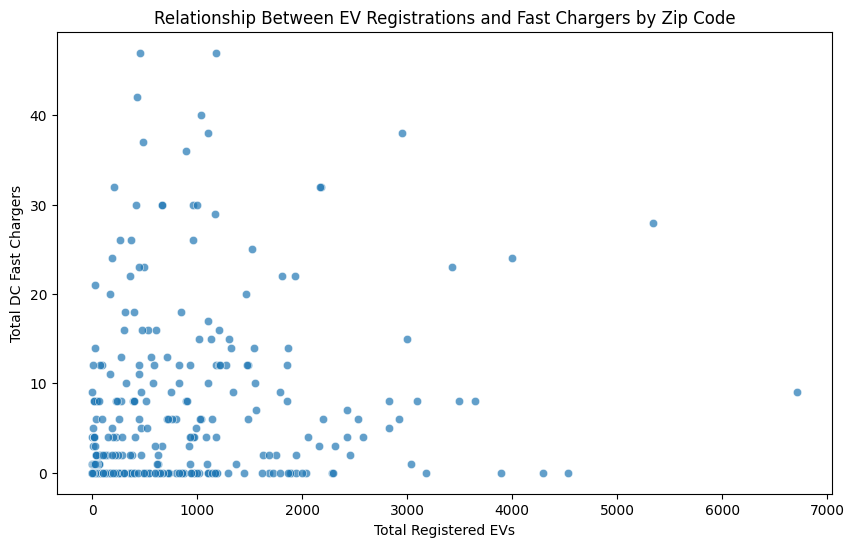

In [39]:
#Visual 1

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_grouped, x='total_evs', y='total_chargers', alpha=0.7)
plt.title('Relationship Between EV Registrations and Fast Chargers by Zip Code')
plt.xlabel('Total Registered EVs')
plt.ylabel('Total DC Fast Chargers')

#Save image
plt.savefig('visual_1_scatter.png')

**Answer to Research Question (Visual 1):**

The scatter plot helps answer the question by visualizing the direct correlation between the two variables. We can observe whether areas with high concentrations of registered EVs also see a proportional increase in DC fast charging stations.

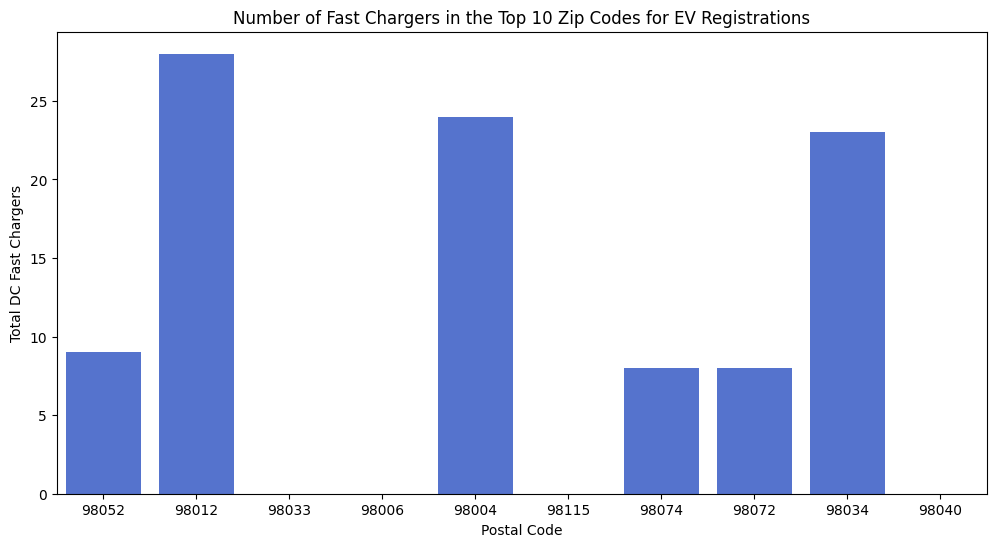

In [40]:
#Sort grouped data to find top 10 zip codes with most EVs
top_10_ev_zips = df_grouped.sort_values(by='total_evs', ascending=False).head(10)

#Create visual 2


plt.figure(figsize=(12,6))
sns.barplot(data=top_10_ev_zips, x='postal_code', y='total_chargers', color='royalblue')
plt.title('Number of Fast Chargers in the Top 10 Zip Codes for EV Registrations')
plt.xlabel('Postal Code')
plt.ylabel('Total DC Fast Chargers')
plt.savefig('visual2_bat.png')

**Answer to Question (Visual 2):**

This chart isolates the top 10 zip codes with EVs and shows exactly how much fast chargers exist in those specific areas. It reveals where the fast-charging infrastructure is keeping up in heavily EV populations in Washington state.

## REFLECTION ##

If I had more time to complete the project, I would explore the nested JSON structures from the NREL API to extract more variables like pricing structures and connector types. I would spend more time standardizing the Washington EV registration text field, specifically identifying hidden inconsistencies or typos within vehicle "Make" and "Model" columns. Cleaning those text fields would allow me to expand my research question to explore which EV manufacturers are most popular at zip codes with more fast chargers.
